In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, recall_score,
    roc_auc_score, average_precision_score, cohen_kappa_score,
    precision_recall_curve, PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

## Data preparation

In [2]:
# =====================
# 1. Prepare Data
# =====================

# Load data
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [3]:
# ===================
# 2. Base Decision Tree Model (SMOTE outside pipeline)
# ===================
base_dt = DecisionTreeClassifier(random_state=42)
base_dt.fit(X_train_sm, y_train_sm)

# Predict
y_pred_base = base_dt.predict(X_test)
y_proba_base = base_dt.predict_proba(X_test)[:, 1]
y_train_pred_base = base_dt.predict(X_train_sm)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[490 217]
 [192 412]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.718     0.693     0.706       707
           1      0.655     0.682     0.668       604

    accuracy                          0.688      1311
   macro avg      0.687     0.688     0.687      1311
weighted avg      0.689     0.688     0.688      1311

------------------------------------------------------
Test Avg Precision: 0.595
Test AUC: 0.689
Test Cohen's Kappa: 0.374
Training recall: 0.986


In [4]:
# ===================
# 3. Tuned Decision Tree (SMOTE in pipeline)
# ===================
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'dt__max_depth': [10, 15, None],
    'dt__min_samples_split': [2, 5, 10, 12],
    'dt__min_samples_leaf': [1, 2, 4],
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_features': [None, 'sqrt', 'log2']
}

grid_dt = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    n_jobs=-1,
    verbose=2
)

grid_dt.fit(X_train, y_train)

# Predict
best_dt = grid_dt.best_estimator_
y_pred_tune = best_dt.predict(X_test)
y_proba_tune = best_dt.predict_proba(X_test)[:, 1]
y_train_pred_tune = best_dt.predict(X_train)

# Evaluation
print("Best Parameters:", grid_dt.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tune))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_tune, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tune):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tune):.3f}")

Fitting 15 folds for each of 216 candidates, totalling 3240 fits
Best Parameters: {'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__max_features': None, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 12}
------------------------------------------------------
[[534 173]
 [180 424]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.748     0.755     0.752       707
           1      0.710     0.702     0.706       604

    accuracy                          0.731      1311
   macro avg      0.729     0.729     0.729      1311
weighted avg      0.731     0.731     0.731      1311

------------------------------------------------------
Test Avg Precision: 0.789
Test AUC: 0.802
Test Cohen's Kappa: 0.458
Training recall: 0.750


### 95% CI on Recall

Recall 95% CI: (0.663, 0.739)


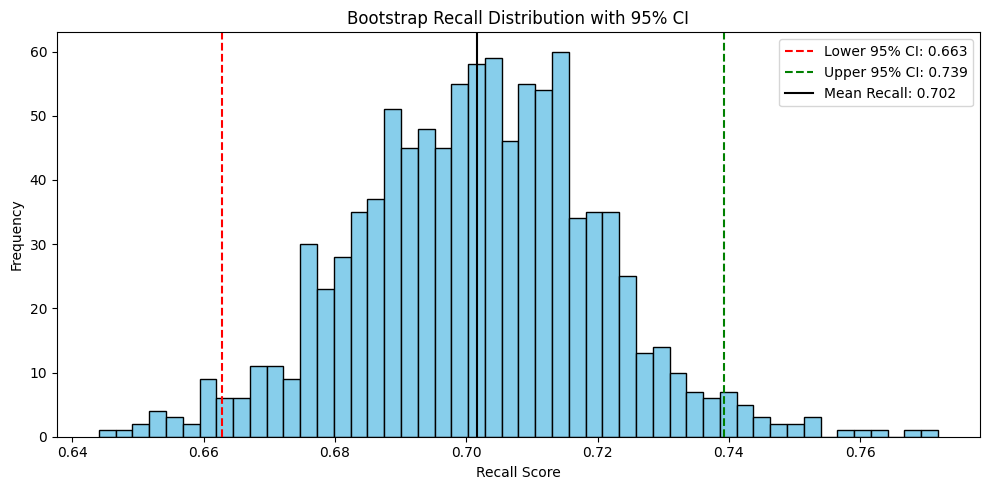

In [5]:
# Bootstrap
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_dt.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Feature importance

             Feature  Base Importance  Tuned Importance
1       child weight         0.382165          0.418507
0          child age         0.150396          0.343047
8       wealth index         0.108180          0.053866
5          child sex         0.034209          0.051299
6   mother education         0.071893          0.021091
12           madhesh         0.027745          0.014917
4               area         0.039862          0.014673
9            gandaki         0.030411          0.014254
13           lumbini         0.023864          0.014043
3              fever         0.037654          0.012468
14     sudurpashchim         0.021055          0.011787
2          diarrhoea         0.017086          0.011438
11             koshi         0.024825          0.008686
10           karnali         0.020193          0.005945
7   health insurance         0.010463          0.003981


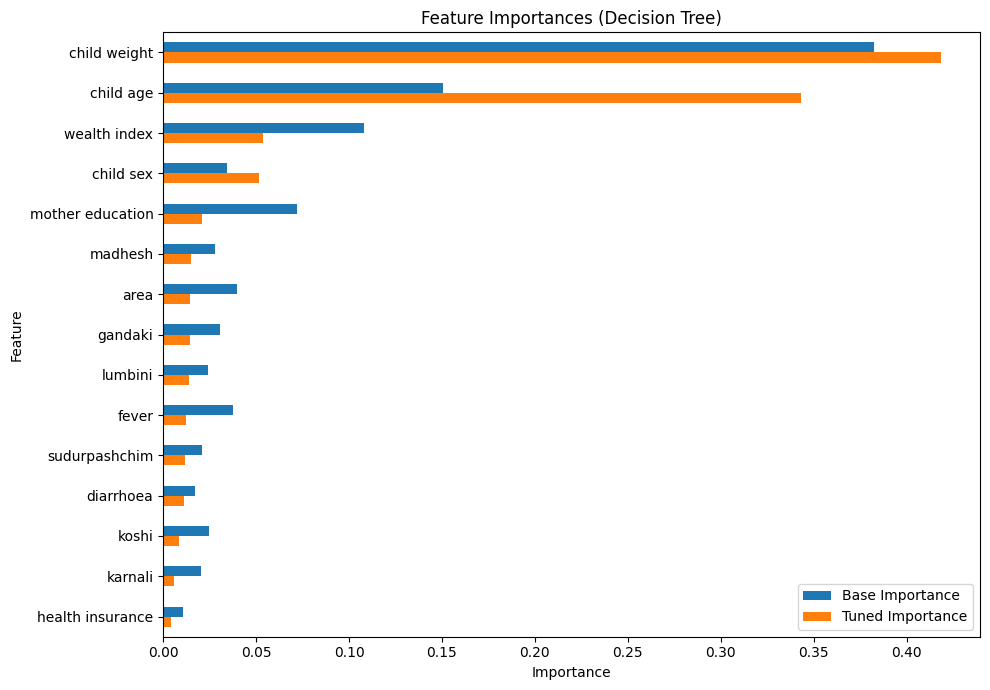

In [6]:
# Get feature names
feature_names = X.columns

# Extract the Decision Tree model from the pipeline
dt_tuned_model = best_dt.named_steps['dt']  # from pipeline
dt_base_model = base_dt  # directly used without pipeline

# Get feature importances
importances_base = dt_base_model.feature_importances_
importances_tuned = dt_tuned_model.feature_importances_

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Base Importance': importances_base,
    'Tuned Importance': importances_tuned
}).sort_values(by='Tuned Importance', ascending=False)

print(importance_df)

# Plot
top_features = importance_df.set_index('Feature')

top_features.plot(kind='barh', figsize=(10, 7))
plt.title('Feature Importances (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(False)
plt.tight_layout()
plt.show()


### Average Precision Plot

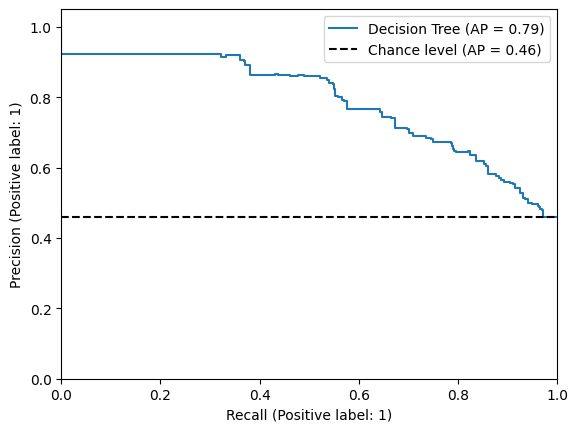

In [12]:
display = PrecisionRecallDisplay.from_estimator(
    best_dt,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="Decision Tree",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

# display.ax_.set_title("Decision Tree Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

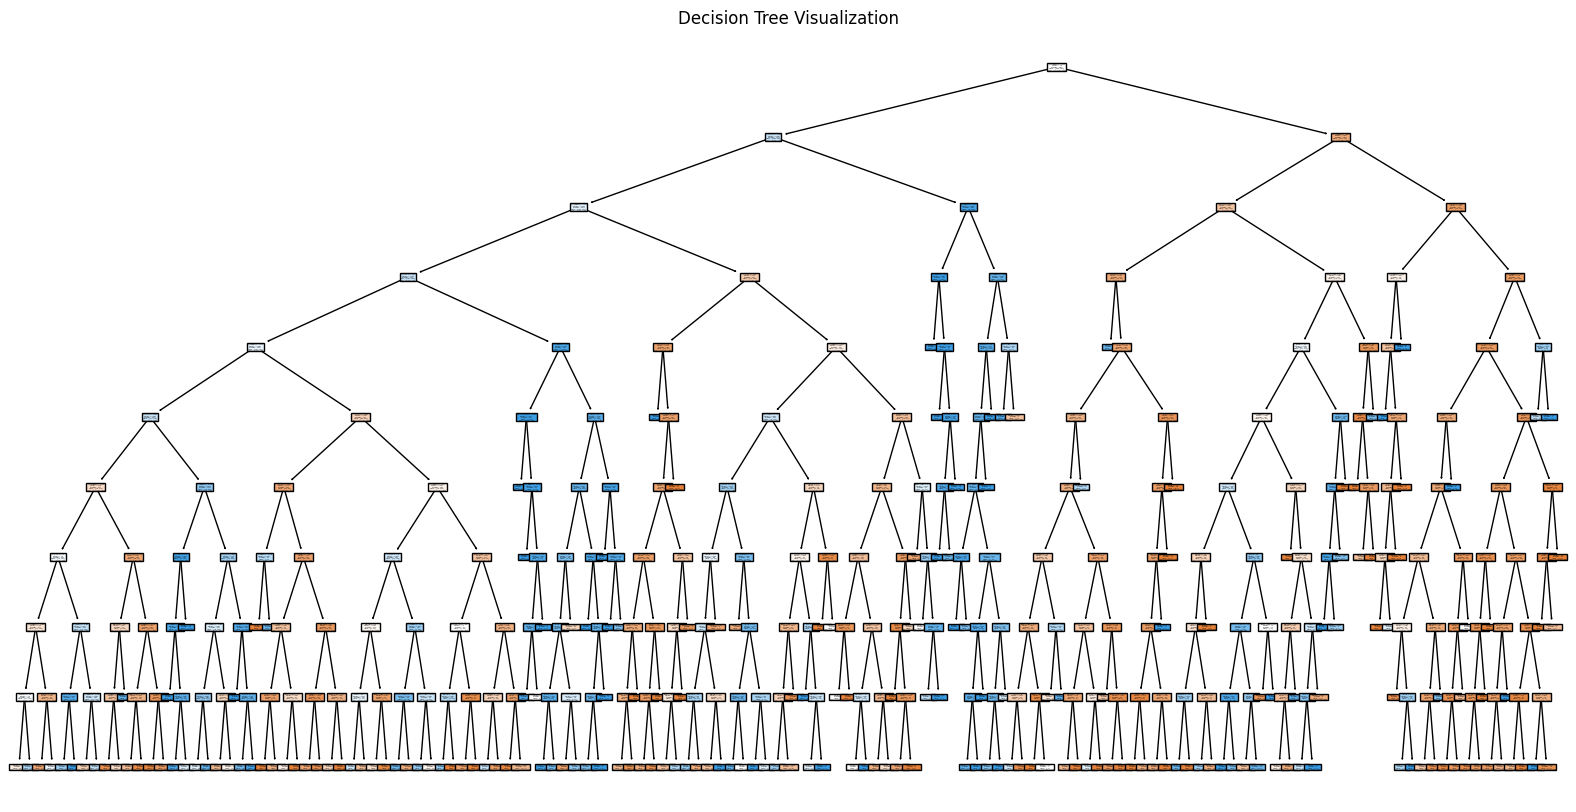

In [8]:
# Extract the DecisionTreeClassifier from the pipeline
dt_model = best_dt.named_steps['dt']

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Not Malnourished', 'Malnourished'],
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

## Additional

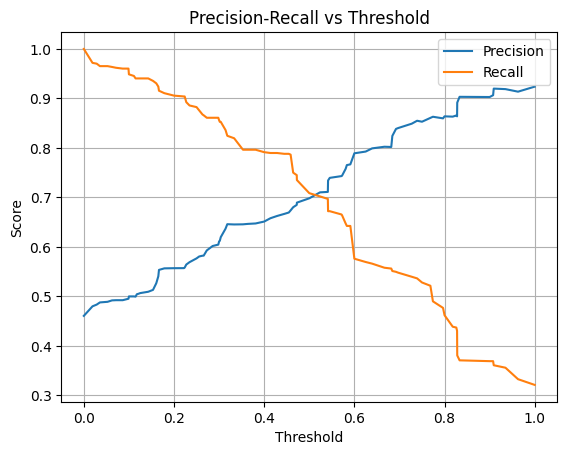

In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [10]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.64      0.70       707
           1       0.65      0.79      0.71       604

    accuracy                           0.71      1311
   macro avg       0.72      0.71      0.71      1311
weighted avg       0.72      0.71      0.71      1311


